# Extrapolated BCD algorithms for unconstrained matrix and tensor decompositions

:::{admonition} Reference
:class: tip
{cite:p}`Ang2019acceleratingB` A. Ang, J. E. Cohen, L. K. Hien, N. Gillis, "Extrapolated Alternating Algorithms for Approximate Canonical Polyadic Decomposition", ICASSP2020, [pdf](https://arxiv.org/pdf/2001.04321).

{cite:p}`ang2020accelerating` A. M. S. Ang, J. E. Cohen, N. Gillis, L. T. K. Hien, "Accelerating Block Coordinate Descent for Nonnegative Tensor Factorization", Numerical Linear Algebra Appl., 2021;e2373. [pdf](https://hal.science/hal-02330641)
:::

Among various techniques to speed up first-order optimization algorithms for convex smooth problems, extrapolated (also called inertial) algorithms are especially popular. The theory of extrapolated algorithms such as Nesterov projected gradient descent (also called FISTA or inertial Forward Backward) is now rather well understood: while the convergence rate of gradient descent for smooth strongly convex cost functions is at worse $\mathcal{O}(\frac{1}{k})$, Nesterov gradient descent converges with rate $\mathcal{O}(\frac{1}{k^2})$. This improvement comes at almost no additional cost in terms of memory or computation. In essence, extrapolated first-order algorithms minimize a cost function $f(x)$, where $x$ must belong to a convex set $\mathcal{C}$, with iterates of the form

$$
    x_{k+1} &= \mathcal{\Pi}_{\mathcal{C}}\left[ y_{k} - \eta \nabla_f (y_k) \right] \\
    y_{k+1} &= x_{k+1} + \beta_k (x_{k+1} - x_k)
$$

where $y_{k}$ and $x_{k}$ are the auxiliary and principal sequences of iterations at iteration $k$, $\mathcal{\Pi}_{\mathcal{C}}$ is the projection on convex set $\mathcal{C}$ and $\alpha_k$ is an extrapolation parameter dependent on the iteration index. Various formulations have been proposed for the choice of $\alpha_k$. The convergence of such a scheme was proved first by Nesterov {cite:p}`Nesterov1983method`, but later analyzed more generally as discretized second-order differential equations {cite:p}`Attouch2013Convergence` [TODO check ref]. Interestingly, the cost function may increase with Nesterov gradient descent. O’Donoghue and Candès have proposed a restart strategy to further speed up convergence {cite:p}`o2015adaptive`. Restart consists in resetting the value of $\beta_k$ to ensure that the cost decreases.

## Extrapolated block-coordinate algorithms for LRA

Extending inertial extrapolation strategies for LRA is not straightforward. Indeed, extrapolated algorithms were initially proposed for convex problems, but LRA optimization problems are, in general, multiblock and non-convex. A simple approach would be to use extrapolated algorithms to solve each block in an alternating algorithm. In {cite:p}`Ang2019acceleratingB` and {cite:p}`ang2020accelerating`, we proposed an empirical strategy to perform extrapolation for BCD algorithms after the BCD updates, at the outer loop level. In other words, we extrapolate the estimated block of variables after the update, using the previous block estimate. This is fundamentally different from extrapolation within each block. This work has spurred a series of more principled works, in which I was not involved, led by Lee Ti Hien Khan and Nicolas Gillis, that propose extrapolated BCD algorithms with convergence guarantees and good empirical performance {cite:p}`hienInertialBlockMajorization2023`, {cite:p}`hienBlockMajorizationMinimization2025`. Other works in the literature have studied extrapolated block coordinate descent; see, for instance, the iPALM algorithm {cite:p}`Pock2016`. The main difference between iPALM and subsequent works by Khan, in particular TITAN, is that iPALM alternates between extrapolated gradient steps, whereas TITAN studies a broader class of alternating inertial MM algorithms, including iPALM.

Another work, published almost simultaneously and closely related to ours, proposes an extrapolated ALS algorithm for CPD with restart {cite:p}`mitchell2020nesterov`. 

## Heuristic Extrapolation with Restart

The Heuristic Extrapolation with Restart (HER) framework takes the idea of Nesterov projected gradient but applies it to a full BCD cycle. For simplicity, let us apply the HER framework to a specific model: nonnegative CPD,

$$
    \argmin{X_i\geq 0} \|\mathcal{T} -  \mathcal{I}_r \times_1 X_1 \times_2 X_2 \times_3 X_3 \|^2_F .
$$

A vanilla BCD algorithm for nCPD is ANLS, using a generic NNLS solver, which writes as follows for the $k$-th iteration:

$$
    X^{k+1}_{1} &= \argmin{X_1\geq 0} \|T_{[1]} - X_1 \left(X^{k}_2\odot X^{k}_3\right) \|_F^2 \\
    X^{k+1}_{2} &= \argmin{X_2\geq 0} \|T_{[2]} - X_2 \left(X^{k+1}_1\odot X^{k}_3\right) \|_F^2 \\
    X^{k+1}_{3} &= \argmin{X_3\geq 0} \|T_{[3]} - X_3 \left(X^{k+1}_1\odot X^{k+1}_2\right) \|_F^2.
$$

In contrast, HER-ANLS extrapolates the estimates $X^{k+1}$ based on the NNLS estimation and the previous value, both taken in a pairing sequence $Y^{k}$, as follows:

$$
    Y^{k+1}_{1} &= \argmin{Y_1\geq 0} \|T_{[1]} - Y_1 \left(X^{k}_2\odot X^{k}_3\right) \|_F^2 \\
    X^{k+1}_{1} &= \max\left( Y^{k+1}_{1} + \beta_k \left( Y^{k+1}_1 - Y^{k}_1 \right), 0\right) \\
    Y^{k+1}_{2} &= \argmin{Y_2\geq 0} \|T_{[2]} - Y_2 \left(X^{k+1}_1\odot X^{k}_3\right) \|_F^2 \\
    X^{k+1}_{2} &= \max\left( Y^{k+1}_{2} + \beta_k \left( Y^{k+1}_2 - Y^{k}_2 \right), 0\right) \\
    Y^{k+1}_{3} &= \argmin{Y_3\geq 0} \|T_{[3]} - Y_3 \left(X^{k+1}_1\odot X^{k+1}_2\right) \|_F^2 \\
    X^{k+1}_{3} &= \max\left( Y^{k+1}_{3} + \beta_k \left( Y^{k+1}_3 - Y^{k}_3 \right), 0\right).
$$

To ensure that the cost function does not increase significantly, HER also performs a restart operation and updates the extrapolation hyperparameters in consequence. The following code implements HER-ANLS, simplified from the presentation in {cite:p}`ang2020accelerating`, which used an additional pairing sequence to ensure that the cost function decreases.

In [ ]:
from copy import deepcopy
import numpy as np
import tensorly as tl
from tensorly.solvers.nnls import hals_nnls 
from tensorly.tenalg import unfolding_dot_khatri_rao
from tensorly_hdr.gradients import get_pseudo_inverse, err_calc_simple
from tensorly.decomposition import non_negative_parafac_hals

In [ ]:

# HER-ANLS
def HER_ANLS(data, rank, cp_e, beta=0.1, gamma=1.05, eta=2.0, itermax=100):
    """    
    HER-ANLS: Heuristic Extrapolated Alternating Nonnegative Least Squares for Nonnegative Canonical Polyadic Decomposition (nCPD).
    """
    # Initialize factor matrices and auxilliary factor matrices
    cp_y = deepcopy(cp_e) 
   
    # Initialize hyperparameters
    norm_tensor = tl.norm(data, 2)
    err = [tl.norm(data - cp_e.to_tensor())]  # Initial error.
   
    # Outer iteration loop 
    for k in range(itermax):
        # loop on the modes of the tensor
        for mode in range(data.ndim):
            # Computing MTTKRP and pseudo-inverse
            pseudo_inverse = get_pseudo_inverse(cp_e, rank, mode, data)
            mttkrp = unfolding_dot_khatri_rao(data, cp_e, mode)

            factor_old = np.copy(cp_y[1][mode])
            # Call the hals resolution with nnls, optimizing the current mode, inplace update
            hals_nnls(
                tl.transpose(mttkrp),
                pseudo_inverse,
                tl.transpose(cp_y[1][mode]),
                n_iter_max=100,
            )
            
            # Extrapolation step, store temporarily to check for restart
            cp_e[1][mode] = tl.maximum(
                cp_y[1][mode] + beta * (cp_y[1][mode] - factor_old), 0
            )
        
        # Check for restart
        current_err = err_calc_simple(cp_e, mttkrp, norm_tensor)
        if k>0 and current_err > err[-1]: 
            ## Restart the extrapolation, cost increased
            cp_e = deepcopy(cp_y)
            beta = beta/eta  # decrease beta
            err.append(tl.norm(data - cp_e.to_tensor())/norm_tensor)
        else:
            ## More aggressive extrapolation
            beta = tl.minimum(beta*gamma, 1)  # increase beta
            err.append(current_err)
        
    return cp_e, err

New iteration 
 0
betas 0.01 1.0
Current error 0.8277379840954153
New iteration 
 1
betas 0.012 1.0
Current error 0.23312703502327978
New iteration 
 2
betas 0.0144 1.0
Current error 0.14832731699094032
New iteration 
 3
betas 0.01728 1.0
Current error 0.06878535641752749
New iteration 
 4
betas 0.020736 1.0
Current error 0.030893712463470342
New iteration 
 5
betas 0.0248832 1.0
Current error 0.0202877580611402
New iteration 
 6
betas 0.02985984 1.0
Current error 0.017351176405766517
New iteration 
 7
betas 0.035831808 1.0
Current error 0.015102313968171322
New iteration 
 8
betas 0.0429981696 1.0
Current error 0.013139051573418839
New iteration 
 9
betas 0.05159780351999999 1.0
Current error 0.011413558644487794
New iteration 
 10
betas 0.06191736422399999 1.0
Current error 0.009891233544703051
New iteration 
 11
betas 0.07430083706879999 1.0
Current error 0.008545689616733257
New iteration 
 12
betas 0.08916100448255998 1.0
Current error 0.007354212912805134
New iteration 
 13
betas

Let us test the HER-ANLS algorithm on a simple nCPD problem with small dimensions and almost no noise.

In [ ]:
# Hyperparameters
rank = 2
dims = [6,6,6]
noise = 1e-7
# Generate a random nCPD problem
np.random.seed(42)  # For reproducibility
cp_true = tl.random.random_cp(dims, rank) # rank 2, dim 10x10x10
cp_true[0] = None # no weights
init_cp = tl.random.random_cp(dims, rank)
init_cp[0] = None
for i in range(3):
    cp_true[1][i] = tl.maximum(cp_true[1][i],0)
    init_cp[1][i] = tl.maximum(init_cp[1][i],0)
T = cp_true.to_tensor() + noise*tl.random.random_tensor(shape=dims)  # Add some noise
# Computing the nCPD with HER-ANLS
cp_e, err = HER_ANLS(T, rank, deepcopy(init_cp), itermax=100, beta=0.01, gamma=1.2, eta=5)
# Comparison with tensorly nn_cp hals
err_hals = []
def err_ret(_,a):
    # non_negative_parafac_hals returns a tuple (cp, err, loss) with a 1/2 coefficient for the Frobenius norm
    err_hals.append(a)
out2 = non_negative_parafac_hals(T, rank, init=deepcopy(init_cp), callback=err_ret, n_iter_max=100, tol=0)

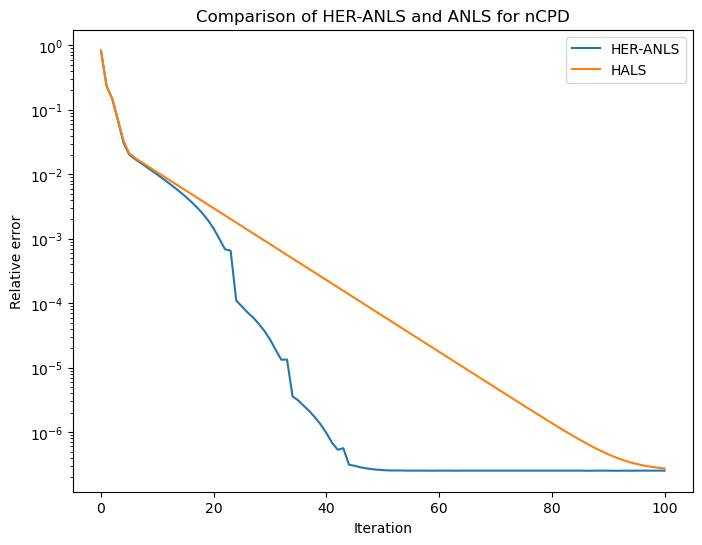

In [101]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.semilogy(err, label='HER-ANLS')
plt.semilogy(err_hals, label='HALS')
plt.xlabel('Iteration')
plt.ylabel('Relative error')
plt.legend()
plt.title('Comparison of HER-ANLS and ANLS for nCPD')
plt.show()

Note that the main hyperparameters for HER-ANLS are
- $\gamma$: the amount by which the extrapolation parameter is multiplied at each iteration.
- $\eta$: the amount by which the extrapolation parameter is divided when restart occurs.